In [1]:
from scr.SPMe import Solid_Phase, Cell
from scr.utils.pinn import FFNN, DeepONet, NN_TL_Diffusion, DeepONet_TL
from scr.utils.sampling import Sampler, Sampler_DONet
from scr.utils.parameters import load_params
from scr.utils.profiles import zheng_current, constant
from scr.utils.optimizers import NTK_Adaptive, Adam_Custom

import pybamm
import torch
import numpy as np
import time
import pickle as pkl
import os

import matplotlib.pyplot as plt

np.set_printoptions(precision=3)
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
print("Device: ", device, "\n")
# print(torch.get_num_threads())
torch.set_num_threads(1)

Device:  cpu 


In [2]:
def RMSELoss(yhat, y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [13]:
crate = -1.

file = "2024-10-28_09-14"
iter = ""
if iter != "":
    fold = os.path.join("..\\models", file, iter)
else:
    fold = os.path.join("..\\models", file)

# Run PyBaMM simulation
param = pybamm.ParameterValues("Chen2020")

PBM_model = pybamm.lithium_ion.SPM()

experiment = pybamm.Experiment(["Charge at 1C for 100000 seconds or until 4.2 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
solution = sim.solve(initial_soc=0.)

t = solution["Time [s]"].entries
V = solution["Terminal voltage [V]"].entries

# PybaMM concentrations
c_s_n = solution["Negative particle concentration"]
c_s_p = solution["Positive particle concentration"]
r_n = solution["r_n [m]"].entries[:, 0, 0]
r_p = solution["r_p [m]"].entries[:, 0, 0]
t_pbm = solution["Time [s]"].entries
x = solution["x [m]"].entries[:, 0]

c_p_pbm = c_s_p(r=r_p[-1], t=t, x=x[-1])
c_n_pbm = c_s_n(r=r_n[-1], t=t, x=x[0])

c_p_pbm_0 = c_s_p(r=r_p[0], t=t, x=x[-1])
c_n_pbm_0 = c_s_n(r=r_n[0], t=t, x=x[0])


parameters = load_params()
# Pybamm takes stechiometric coefficients differently, so we need to adjust the parameters
parameters["SOL_p"][0] = c_p_pbm[0]
parameters["SOL_n"][0] = c_n_pbm[0]

training_points = {"PDE": {"type": "PDE", "N": 1000},
                   "IV": {"type": "IV", "N": 100},
                   "BC_Center": {"type": "BC", "N": 100, "BC_pos": 0.},
                   "BC_Surf": {"type": "BC", "N": 100, "BC_pos": 1.}}
validation_points = {"PDE": {"type": "PDE", "N": 30},
                     "IV": {"type": "IV", "N": 15},
                     "BC_Center": {"type": "BC", "N": 15, "BC_pos": 0.},
                     "BC_Surf": {"type": "BC", "N": 15, "BC_pos": 1.}}

model_p = DeepONet_TL(branch_layers=[64, 64, 64, 64], trunk_layers=[64, 64, 64, 64], fine_layers=[32, 32],
                      dim_branch=360, dim_trunk=3, dim_int=128, dim_out=1, dropout=0.).to(device)
pos_model = Solid_Phase(model_p, parameters, [1., 1., 1.], criterion=RMSELoss, electrode="pos").to(device)

model_n = DeepONet_TL(branch_layers=[64, 64, 64, 64], trunk_layers=[64, 64, 64, 64], fine_layers=[32, 32],
                      dim_branch=360, dim_trunk=3, dim_int=128, dim_out=1, dropout=0.).to(device)
neg_model = Solid_Phase(model_n, parameters, [1., 1., 1.], criterion=RMSELoss, electrode="neg").to(device)

PINN = Cell(pos_model, neg_model)

PINN.pos_model.load_model(os.path.join(fold, "TL_pos.pt"))
PINN.neg_model.load_model(os.path.join(fold, "TL_neg.pt"))

with open(os.path.join(fold, "Weights.pkl"), "rb") as input_file:
    weights = pkl.load(input_file)
PINN.pos_model.weights = weights["P"]
PINN.neg_model.weights = weights["N"]

cur_fun = constant(crate)

pinn_sample_t_0 = torch.linspace(0, 1, 100)
pinn_sample_r = torch.ones_like(pinn_sample_t_0)
pinn_sample_I = torch.tensor(cur_fun(pinn_sample_t_0.numpy() * 3600.))
pinn_sample = torch.stack([pinn_sample_t_0, pinn_sample_r, pinn_sample_I]).t()

N = torch.tensor(cur_fun(np.arange(0., 3600, 10)))

V_pinn_0 = PINN.compute_V((pinn_sample, N))
c_p_0 = PINN.pos_model((pinn_sample, N))
c_n_0 = PINN.neg_model((pinn_sample, N))
t_pinn_0 = pinn_sample_t_0.detach().numpy()

# plot_voltage_components(solution, PINN, (pinn_sample, N))

In [14]:
num = 1000.
PINN.neg_model.params["SOC_0"] = 0.
PINN.pos_model.params["SOC_0"] = 0.

t_test = (torch.arange(0, num, dtype=torch.float, requires_grad=True)/num)[::10]
r_rand = (torch.arange(0, num, dtype=torch.float, requires_grad=True)/num)[::10]

t_new, r_new = torch.meshgrid(t_test, r_rand)
pos = np.zeros_like(t_new.detach().numpy())
neg = np.zeros_like(t_new.detach().numpy())
I_test = torch.tensor(cur_fun(t_new.detach().numpy() * 3600.))
N = torch.tensor(cur_fun(np.arange(0., 3600, 10)))

pos_dcdt = np.zeros_like(t_new.detach().numpy())
neg_dcdt = np.zeros_like(t_new.detach().numpy())
pos_dcdr = np.zeros_like(t_new.detach().numpy())
neg_dcdr = np.zeros_like(t_new.detach().numpy())

pos_c = np.zeros_like(t_new.detach().numpy())
neg_c = np.zeros_like(t_new.detach().numpy())

for i, (t, r, I_t) in enumerate(zip(t_new, r_new, I_test)):

  residuals = PINN.pos_model.compute_residuals((torch.stack((t, r, I_t)).t(), N))
  pos[i, :] = np.abs(residuals.detach().numpy())
  gradients = PINN.pos_model.compute_gradients((torch.stack((t, r, I_t)).t(), N))
  pos_dcdt[i, :] = np.abs(gradients[:,0].detach().numpy())
  pos_dcdr[i, :] = np.abs(gradients[:,1].detach().numpy())
  pos_c[i, :] = PINN.pos_model((torch.stack((t, r, I_t)).t(), N)).detach().numpy()
  
  residuals = PINN.neg_model.compute_residuals((torch.stack((t, r, I_t)).t(), N))
  neg[i, :] = np.abs(residuals.detach().numpy())
  gradients = PINN.neg_model.compute_gradients((torch.stack((t, r, I_t)).t(), N))
  neg_dcdt[i, :] = np.abs(gradients[:,0].detach().numpy())
  neg_dcdr[i, :] = np.abs(gradients[:,1].detach().numpy())
  neg_c[i, :] = PINN.neg_model((torch.stack((t, r, I_t)).t(), N)).detach().numpy()

In [15]:
def plot_area(points, style, cmap_label):
    plt.subplots(figsize=(7,3), tight_layout=True)
    plot = plt.pcolormesh(t_new.detach().numpy(), r_new.detach().numpy(), points, cmap=style, shading='gouraud')
    cbar = plt.colorbar(plot)
    plt.contour(t_new.detach().numpy(), r_new.detach().numpy(), points, 10, colors='gray')
    plt.ylabel('$r$')
    plt.xlabel('$t$ [h]')
    cbar.set_label(cmap_label)
    # plt.savefig('/content/drive/MyDrive/Datos/con_PINN_pos.png')
    plt.show()

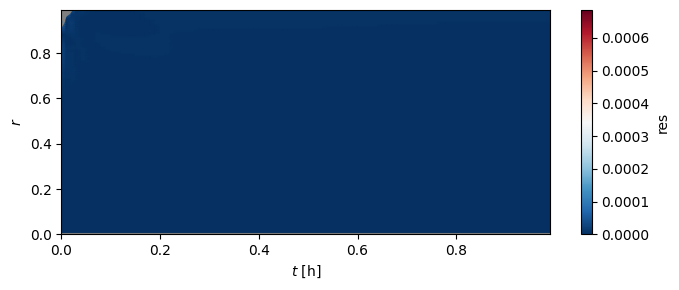

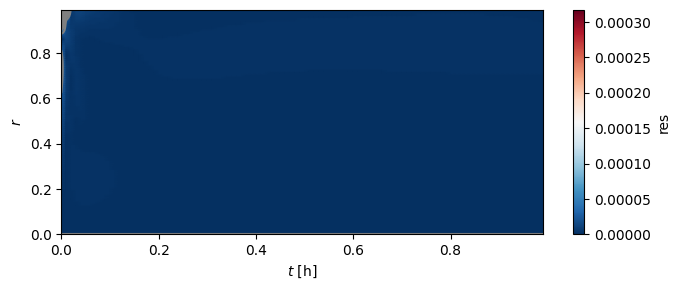

In [16]:
plot_area(pos, 'RdBu_r', 'res')
plot_area(neg, 'RdBu_r', 'res')

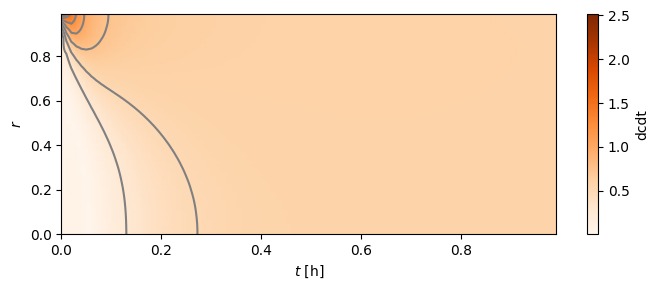

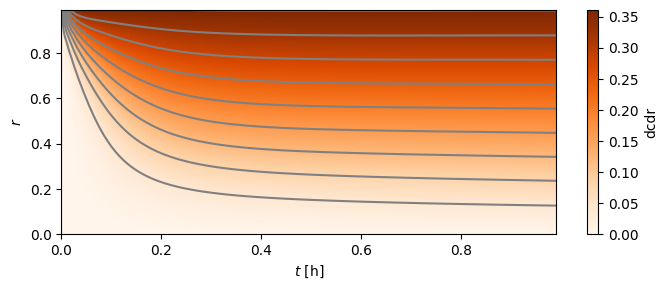

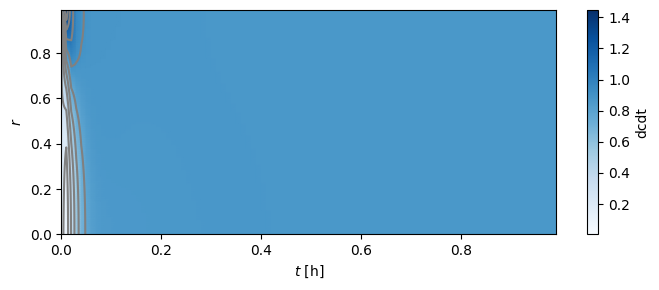

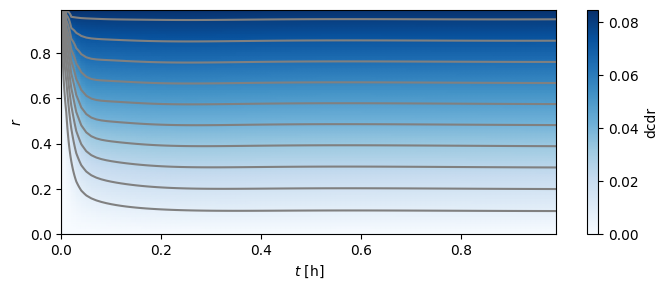

In [17]:
plot_area(pos_dcdt, 'Oranges', 'dcdt')
plot_area(pos_dcdr, 'Oranges', 'dcdr')
plot_area(neg_dcdt, 'Blues', 'dcdt')
plot_area(neg_dcdr, 'Blues', 'dcdr')

In [8]:
PINN.neg_model.params["SOC_0"] = 0.
PINN.pos_model.params["SOC_0"] = 0.

pinn_sample_t = torch.linspace(0, 1, 100)
pinn_sample_r = torch.ones_like(pinn_sample_t)
pinn_sample_I = torch.tensor(cur_fun(pinn_sample_t.numpy() * 3600.))
pinn_sample_r1 = torch.stack([pinn_sample_t, pinn_sample_r, pinn_sample_I]).t()

N = torch.tensor(cur_fun(np.arange(0., 3600, 10)))

c_p_1 = PINN.pos_model((pinn_sample_r1, N))
c_n_1 = PINN.neg_model((pinn_sample_r1, N))
t_pinn = pinn_sample_t.detach().numpy()

pinn_sample_r = torch.zeros_like(pinn_sample_t)
pinn_sample_r0 = torch.stack([pinn_sample_t, pinn_sample_r, pinn_sample_I]).t()

N = torch.tensor(cur_fun(np.arange(0., 3600, 10)))

c_p_0 = PINN.pos_model((pinn_sample_r0, N))
c_n_0 = PINN.neg_model((pinn_sample_r0, N))

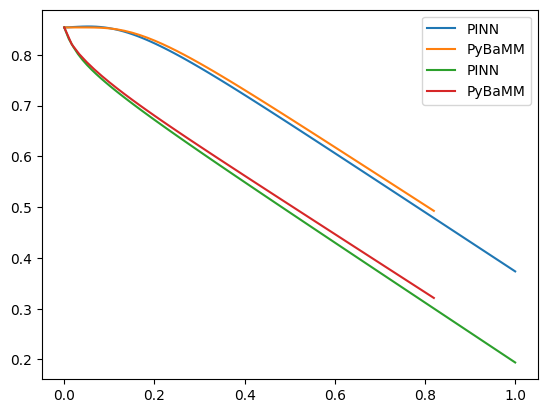

In [9]:
plt.plot(t_pinn, c_p_0.detach().numpy(), label="PINN")
plt.plot(t_pbm/3600., c_p_pbm_0, label="PyBaMM")
plt.plot(t_pinn, c_p_1.detach().numpy(), label="PINN")
plt.plot(t_pbm/3600., c_p_pbm, label="PyBaMM")
plt.legend()
plt.show()

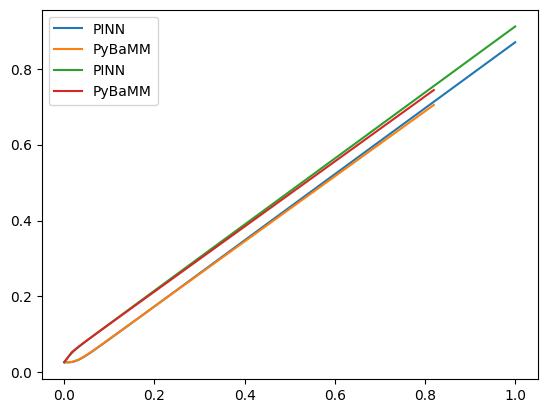

In [10]:
plt.plot(t_pinn, c_n_0.detach().numpy(), label="PINN")
plt.plot(t_pbm/3600., c_n_pbm_0, label="PyBaMM")
plt.plot(t_pinn, c_n_1.detach().numpy(), label="PINN")
plt.plot(t_pbm/3600., c_n_pbm, label="PyBaMM")
plt.legend()
plt.show()

In [11]:
PINN.pos_model.params["SOL_p"]

[0.8539736661258583, 0.2715]

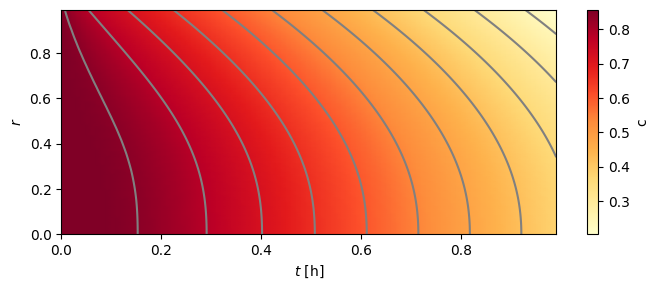

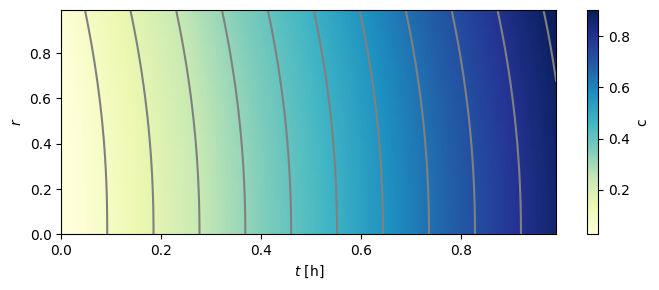

In [18]:
plot_area(pos_c, 'YlOrRd', 'c')
plot_area(neg_c, 'YlGnBu', 'c')

In [27]:
PINN.pos_model.params["D_p"]

4e-15

In [29]:
PINN.neg_model.params["D_n"]

3.3e-14